# Network Science Assignment 6

Author:  
Elias Müller   
18-615-658

Submission Date:  
Monday, 4. November 2024

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import glob
import powerlaw
import numpy as np
from scipy.special import gammaln

In [2]:
def initialize_figure(ROWS, COLS):
    fig, axes = plt.subplots(ROWS, COLS, figsize=(5 * COLS, 5 * ROWS))
    axes = axes.flatten()
    return fig, axes

# set the labels and the title of a given subplot ax
def set_ax_labels(ax, x_label, y_label, title):
    ax.set_xlabel(f"{x_label}")
    ax.set_ylabel(f"{y_label}")
    ax.set_title(f" {title}")

## Task 1

Build networks with the Barabási‑Albert model. Connect m= 3 for each new node and grow until N=
50,100,500,1000,5000, then compute some network properties. Compare them with randomized versions of
the networks.

In [3]:
# In this first part of, we generate the networks following the Barabási‑Albert model, implemented by nx. 
# N = [50, 100, 500, 1000, 5000], m = 3

N = [50, 100, 500, 1000, 5000]
m = 3

# first the original networks (seed set, plus a clique of m = 3 nodes as initial graph - as provided in the lecture notes)
ba_networks = {n: nx.barabasi_albert_graph(n, m, 100, nx.complete_graph(m)) for n in N}

# 20 randomized version per # of the networks
ba_networks_random = {k: [nx.algorithms.smallworld.random_reference(v.copy(), connectivity=False) for _ in range(20)] for k,v in ba_networks.items()}

### Task 1.1
Compute the average clustering coefficient, assortativity, average shortest path length, and diameter.

In [4]:
# original networks
cc_original = {k: nx.average_clustering(v) for k, v in ba_networks.items()}
assortativity_original = {k: nx.degree_assortativity_coefficient(v) for k, v in ba_networks.items()}
avg_path_original = {k: nx.average_shortest_path_length(v) for k, v in ba_networks.items()}
dia_original = {k: nx.diameter(v) for k, v in ba_networks.items()}

# randomized networks calculated mean of the N randomized versions
cc_rand = {k: np.mean([nx.average_clustering(g) for g in v] ) for k, v in ba_networks_random.items()}
assortativity_rand = {k: np.mean([nx.degree_assortativity_coefficient(g) for g in v] ) for k, v in ba_networks_random.items()}
avg_path_rand = {k: np.mean([nx.average_shortest_path_length(g) for g in v] ) for k, v in ba_networks_random.items()}
dia_rand = {k: np.mean([nx.diameter(g) for g in v] ) for k, v in ba_networks_random.items()}

### Task 1.2
Compare them by scatterplots with the same measures on randomized versions of the networks

#### Comments
As outlined in the additional information on the Preferential Attachment tasks (on OLAT) below, we plot the measures of the original Barabási‑Albert network, against an averaged measure of N randomized networks thereof. Further, the axes are log-scaled as required by the task, though I believe this to be redundant for this exercise. To handle the Assortativity, the log scaling was omitted. 

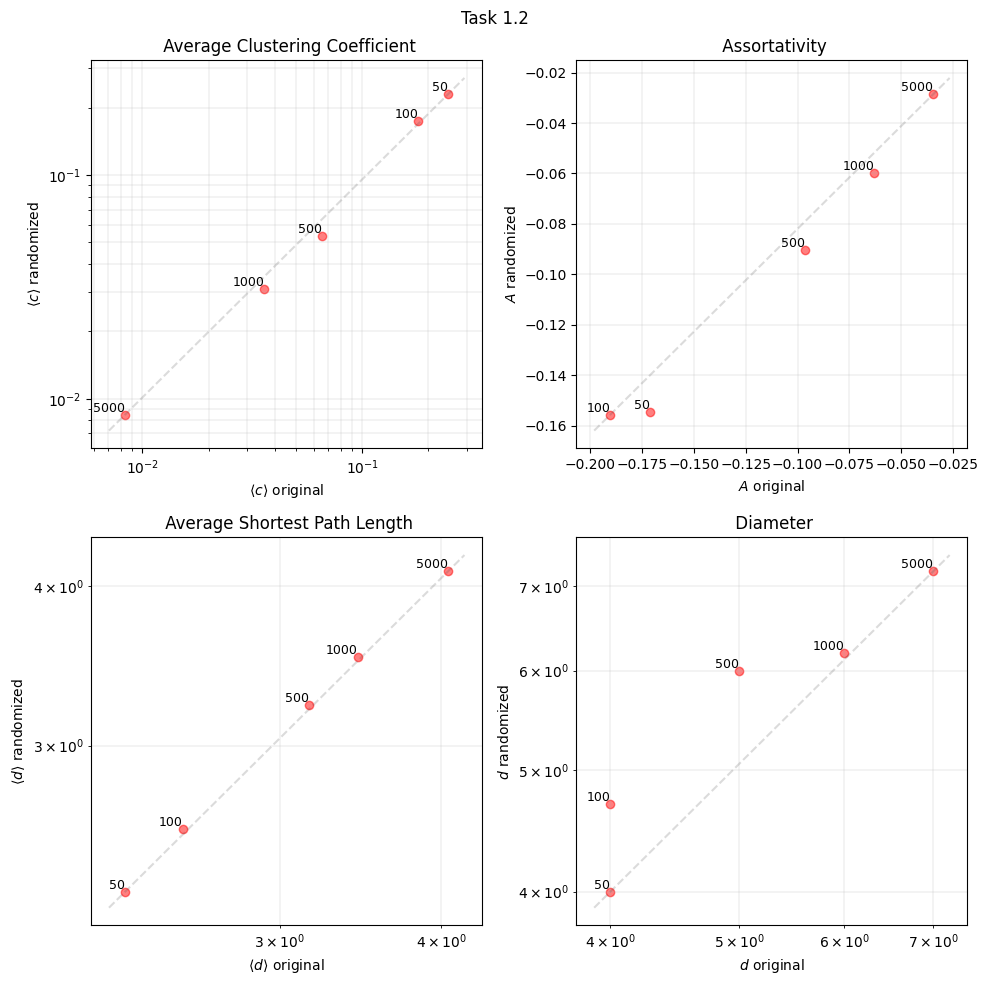

In [11]:
# adds a given set of calculated measures to a scatterplot (original vs. randomized) 
def add_to_scatter(ax, original, rand, title, x_label, y_label):
    ax.scatter(original.values(),
               rand.values(),
               color='red',
               alpha=0.5)
    for key, x, y in zip(original.keys(), original.values(), rand.values()):
        ax.text(x, y, str(key), fontsize=9, ha='right', va='bottom')
    set_ax_labels(ax, x_label, y_label, title)
    if title != "Assortativity": 
        ax.set_xscale('log')
        ax.set_yscale('log')

    ax.grid(True, which='both', linestyle='-', linewidth=0.2)

    ax.plot(ax.get_xlim(), ax.get_ylim(), ls="--", c=".3", alpha=0.2)

labels = [
    ['Average Clustering Coefficient', r'$\langle c \rangle$ original', r'$\langle c \rangle$ randomized'],
    ['Assortativity', '$A$ original', '$A$ randomized'],
    ['Average Shortest Path Length', r'$\langle d \rangle$ original', r'$\langle d \rangle$ randomized'],
    ['Diameter', '$d$ original', '$d$ randomized']
]

original_properties = [cc_original, assortativity_original, avg_path_original, dia_original]
randomized_properties = [cc_rand, assortativity_rand, avg_path_rand, dia_rand]


fig, axes = initialize_figure(2,2)
for i, v in enumerate(original_properties):
    add_to_scatter(axes[i], v, randomized_properties[i], *labels[i])

fig.suptitle("Task 1.2")
fig.tight_layout()


### Task 1.3
Which measures are relatively unchanged by randomization? Why?

- `Average Clustering Coefficient`: The average clustering coefficient appears to be left relatively unaffected by randomization. For higher N networks, a minor clustering loss is measured, which can be explained by the fact that preferential attachment in the Barabasi-Albert model inherently leads to some clustering, that might be impacted slightly by randomization. 

- `Assortativity`: The assortativity, similarly to the average clustering coefficient, is impacted by randomization, but even by a smaller margin (linear scale vs. log scale). Again a small drop is observed, the scale of which, however, approximates zero the larger the network gets. In the original model, some inherent negative assortativity is to be expected, the new unconnected nodes, are attached by preferential attachment. The process of randomization demonstrates that this has a minor 'design' aspect on assortativity.

- `Average Shortest Path Length`: The average shortest path length is relatively unchanged. The changes are minor and in both directions around the original measurement, indicating that no underlying property is influencing the average shortest path length. The fact that randomization preserves hubs (the degrees thereof), appears to be enough to ensure the upkeep of there 'routing' capabilities. 

- `Diameter`: The most impacted measure is undoubtedly the diameter. Overall, the changes are not major, however, more noticeable than for others. Considering the definition of diameter, this comes as no surprise. It is describing the shortest path between the most distanced nodes, i.e. the longest longest shortest path. As we described above, the core hub-structure appears to be kept, thus we do not expect major changes as they should still be able to effectively connect most parts of the graphs, and indeed the data supports this core intuition. Nonetheless, minor shifts in the low connected nodes in the randomization approach, can cause the network to become slightly wider, as the closest hub, might can be somewhat further. It can also be seen that this appears to be compensated with network size. This can be explained by the fact that in these large networks, an 'outlier' chain that causes a large diameter becomes highly unlikely, by few edge swaps.

## Task 2

In [6]:
# load the data
data_paths = glob.glob("data/*.gml")
data_names = [str(x.replace("data/graph_", "")).replace(".gml", "") for x in data_paths]
data_lst = list(map(nx.read_gml, data_paths))

### Task 2.1

Compute the exponent $\gamma$ of the power-law distribution fit $p(k) \sim k^{-\gamma}$ of the network degree distribution and the corresponding error.

#### Comments
The below code is inspired by teh original paper on the powerlaw package: 
[powerlaw: a Python package for analysis of heavy-taileddistributions](https://arxiv.org/pdf/1305.0215)


In [7]:
def powerlaw_Fit(G):
    degrees = sorted([degree for _, degree in G.degree()])
    return powerlaw.Fit(degrees)

powerlaw_Fits = [powerlaw_Fit(x) for x in data_lst]

for i, v in enumerate(powerlaw_Fits):
    print(f"{data_names[i]}: gamma={v.power_law.alpha}, sigma={v.sigma}")


Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
internet: gamma=2.112191339113011, sigma=0.0366878070312722
actors: gamma=2.1609477665039183, sigma=0.003276703809865102
macaque: gamma=17.04488902994108, sigma=4.01122225748527
flavor: gamma=16.088703066926584, sigma=1.5562808921718294


### Task 2.2 

Produce a single plot showing:
- the empirical degree distribution,
- the power‑law fit,
- the Poisson fit,
- the exponential distribution with mean value equal to ⟨k⟩.

Which distribution is more likely to describe the data?

In [8]:
# helper functions to calculate the required measures
def empirical_distribution(G):
    degrees = sorted([degree for _, degree in G.degree()])
    unique_degrees, degree_counts = np.unique(degrees, return_counts=True)
    dist = degree_counts / len(G)
    return unique_degrees, dist

def poisson_distribution(G):
    degrees = sorted([degree for _, degree in G.degree()])
    k_mean = np.mean (degrees)  
    k_vals = range(1, max(np.unique(degrees)))
    dist = []
    for k in k_vals:
        # Avoid direct exponentiation since leads to overflow encountered in scalar power
        # original formula as proposed in the task:
        #p_k = (k_mean**k / factorial(k)) * np.exp(-k_mean)
        # we adapt it like so: 
        # we first take the log of the above and split into parts according to log rules
        # -> k * log(k_mean) - log(k!) - k_mean
        # using gammaln, i.e. the natural logarithm of the factorial (gamma(n)=(n-1)!),
        # we further replace log(k!)
        p_k_log = k * np.log(k_mean) - gammaln(k+1) - k_mean
        p_k = np.exp(p_k_log) # Convert back from log space
        dist.append(p_k)

    return k_vals, dist

def exponential_distribution(G):
    degrees = sorted([degree for _, degree in G.degree()])
    k_mean = np.mean (degrees)  
    k_vals = range(1, max(np.unique(degrees)))
    dist = []
    for k in k_vals:
        p_k = (1/k_mean) * np.exp(-(k/k_mean))
        dist.append(p_k)
    return k_vals, dist

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit


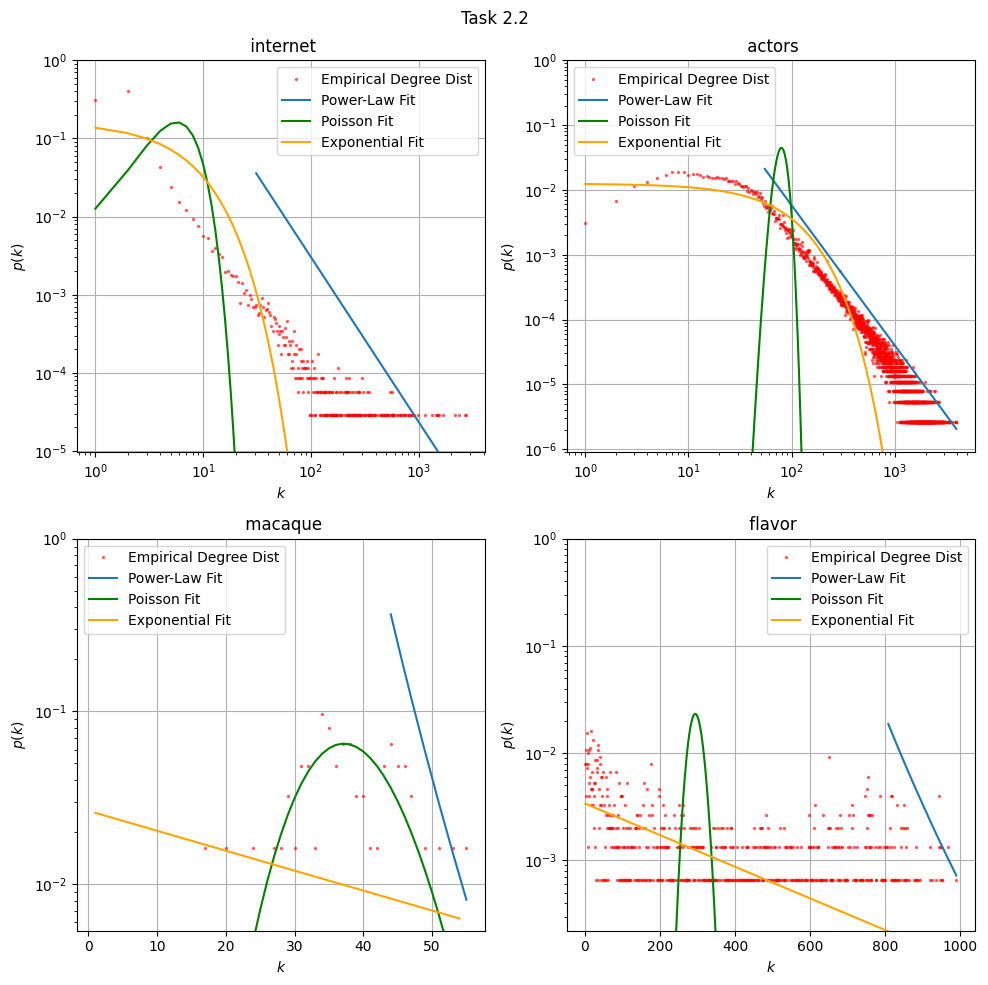

In [9]:
# create one plot per dataset
def add_to_plot(ax, G, title, log_scaled):
    unique_degrees, empirical_dist = empirical_distribution(G)
    ax.plot(unique_degrees, empirical_dist, 'o', markersize=1.5, alpha=0.5, color='red', label=r'Empirical Degree Dist')

    pwl_fit = powerlaw_Fit(G)
    pwl_fit.power_law.plot_pdf(ax=ax, label=r'Power-Law Fit')

    k_values, poisson_dist = poisson_distribution(G)
    ax.plot(k_values, poisson_dist, color='green', label=r'Poisson Fit')

    k_values, exp_dist = exponential_distribution(G)
    ax.plot(k_values, exp_dist, color='orange', label=r'Exponential Fit')       
            
    ax.set_ylim(min(empirical_dist) / 3, 1)
    if log_scaled: ax.set_xscale('log')
    else: ax.set_xscale('linear')
    set_ax_labels(ax,r'$k$', r'$p(k)$', title)
    ax.set_yscale('log')

    ax.grid()
    ax.legend()     

fig, axes = initialize_figure(2,2)
for i, G in enumerate(data_lst):
    log_scaled = False if data_names[i] in ['macaque', 'flavor'] else True
    add_to_plot(axes[i], G, data_names[i], log_scaled)

fig.suptitle("Task 2.2")
fig.tight_layout()

### Task 2.3
Based on the previous plot, say whether the network under consideration is scale‑free or not.

- `Internet`: The Internet shows the characteristics of a **Scale-Free** Network. This follows from the well-alignment with the power-law fit, the empirical data's right skewed distribution (long-tail) and the poor fit with both the poisson and exponential fit.

- `Actors`: While the alignment with the power-law fit is not as close as for the Internet, especially in lower degree nodes, the actors network can still be considered **Scale-Free** for the most part. What speaks against a scale-free distribution, is the fact that the exponential fit approximates the distribution as well quite closely. Further, the paraboloid tendency of the empirical distribution, opposes the scale-free hypothesis. All in all, the alignment with the power-law fit and a right-skewed distribution, still point towards: **Likely Scale-Free**

- `Macaque`: The macaque network is **Not Scale-Free** as it is approximated well by the poisson-distribution, indicating a more homogenous property compared to the heterogenous scale-free networks.

- `Flavor`: The flavor network is **Not Scale-Free**. Again the scattered data does not follow the power-law fit enough to be considered scale-free. The node degree probability is more evenly spread, and its does not appear to exhibit the classic many low-degree, few high-degree node structure.